<a href="https://colab.research.google.com/github/shivansh2310/The-elements-of-quantitative-investing-/blob/main/Portfolio_Optimization_(Chapters_9%E2%80%9310).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* The MVO Framework: Maximize $w^T \mu - \frac{\lambda}{2} w^T \Sigma w$.

* The Estimation Error Problem: MVO is a "maximizer of estimation errors." Because we don't know the true expected returns ($\mu$) or the true covariance ($\Sigma$), the optimizer will overweight assets where the math mistakenly predicts high returns or low volatility.

* Constraints as Priors: When you set a "Long-Only" constraint or a "Sector Neutrality" constraint, you are actually performing a Bayesian operation. You are telling the optimizer: "I don't trust the math's estimate of $\mu$; enforce my belief that these assets shouldn't be shorted."

## Risk-Parity Engine

Instead of just "Mean-Variance" (which relies on your guesses about $\mu$), let's build a Risk Parity model. Risk Parity ignores the (usually wrong) expected returns and focuses purely on the covariance matrix ($\Sigma$) to equalize risk contribution from each sector.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

In [26]:
def etf_data(etf_list):
  data = yf.download(etf_list, period="5y")
  adj_close_price = data['Close']
  return adj_close_price

etf_list = [
    "SPY",  # Market Proxy
    "XLK",  # Technology
    "XLE",  # Energy
    "XLF",  # Financials
    "XLV",  # Health Care
    "XLI",  # Industrials
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLU",  # Utilities
    "XLB",  # Materials
    "XLRE", # Real Estate
    "XLC",  # Communication Services
    "IGF",  # Global Infrastructure
    "DBA"   # Agriculture
]

etf_data = etf_data(etf_list)
etf_data.head()


/tmp/ipykernel_3331/2012890181.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(etf_list, period="5y")
[*********************100%***********************]  14 of 14 completed


Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,
2021-06-09,16.792788,41.269726,393.813843,39.066151,75.375153,23.122942,34.609104,96.191307,67.426193,61.771404,38.385674,28.149408,113.788811,82.313446
2021-06-10,16.889854,41.276714,395.644562,38.830822,75.783928,23.093849,34.205830,95.718735,67.921898,62.157143,38.775726,28.334124,115.735565,82.702293
2021-06-11,16.801613,41.372890,396.298248,38.975643,75.869492,23.014896,34.425804,95.913330,68.326157,62.192219,38.529831,28.398556,114.914421,83.153587
2021-06-14,16.483932,41.495296,397.185608,38.495911,76.373314,22.915155,34.068340,95.477791,69.019203,62.157143,38.750282,28.458694,115.015915,83.177574
2021-06-15,16.342743,41.652672,396.457123,38.414444,75.936028,23.351511,34.132500,95.885506,68.595673,62.008110,38.394157,28.544605,115.052811,82.735901


In [27]:
simple_return = etf_data.pct_change().dropna()
simple_return.head()

Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,
2021-06-10,0.005780,0.000169,0.004649,-0.006024,0.005423,-0.001258,-0.011652,-0.004913,0.007352,0.006245,0.010161,0.006562,0.017108,0.004724
2021-06-11,-0.005225,0.002330,0.001652,0.003730,0.001129,-0.003419,0.006431,0.002033,0.005952,0.000564,-0.006341,0.002274,-0.007095,0.005457
2021-06-14,-0.018908,0.002959,0.002239,-0.012309,0.006641,-0.004334,-0.010384,-0.004541,0.010143,-0.000564,0.005722,0.002118,0.000883,0.000288
2021-06-15,-0.008565,0.003793,-0.001834,-0.002116,-0.005726,0.019042,0.001883,0.004270,-0.006136,-0.002398,-0.009190,0.003019,0.000321,-0.005310
2021-06-16,-0.007019,-0.007976,-0.005583,-0.011074,-0.008763,-0.005339,-0.001074,-0.009470,-0.005402,-0.013290,-0.009055,-0.015049,-0.003849,0.000464


In [28]:
cov_matrix = simple_return.cov()
cov_matrix

Ticker,DBA,IGF,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,
DBA,0.000079,0.000014,0.000016,0.000022,0.000015,0.000040,0.000017,0.000016,0.000018,0.000006,0.000011,0.000006,0.000005,0.000015
IGF,0.000014,0.000078,0.000064,0.000075,0.000060,0.000071,0.000067,0.000067,0.000070,0.000043,0.000076,0.000073,0.000045,0.000073
SPY,0.000016,0.000064,0.000116,0.000101,0.000118,0.000074,0.000101,0.000101,0.000157,0.000045,0.000084,0.000053,0.000065,0.000142
XLB,0.000022,0.000075,0.000101,0.000143,0.000096,0.000099,0.000106,0.000110,0.000118,0.000055,0.000095,0.000064,0.000067,0.000121
XLC,0.000015,0.000060,0.000118,0.000096,0.000170,0.000060,0.000100,0.000094,0.000155,0.000043,0.000083,0.000045,0.000061,0.000151
XLE,0.000040,0.000071,0.000074,0.000099,0.000060,0.000269,0.000094,0.000086,0.000070,0.000033,0.000057,0.000047,0.000039,0.000072
XLF,0.000017,0.000067,0.000101,0.000106,0.000100,0.000094,0.000138,0.000105,0.000112,0.000049,0.000085,0.000055,0.000064,0.000121
XLI,0.000016,0.000067,0.000101,0.000110,0.000094,0.000086,0.000105,0.000121,0.000123,0.000048,0.000087,0.000060,0.000062,0.000121
XLK,0.000018,0.000070,0.000157,0.000118,0.000155,0.000070,0.000112,0.000123,0.000250,0.000039,0.000091,0.000048,0.000068,0.000187


In [29]:
X = simple_return
lw = LedoitWolf()
lw.fit(X)

shrinkage_matrix = lw.covariance_
precesion_matrix = lw.precision_
shrinkage_coef = lw.shrinkage_

# print(f"Shrinkage Matrix:\n{shrinkage_matrix}")
# print(f"Precision Matrix:\n{precesion_matrix}")
print(f"Shrinkage Coefficient: \n{shrinkage_coef}")

Shrinkage Coefficient: 
0.010834433215512475


In [30]:
def get_risk_parity_weights(cov_matrix):
    n = cov_matrix.shape[0]

    # Scale the covariance matrix to annualized terms
    # This makes the numbers large enough for the optimizer to "see"
    cov_annual = cov_matrix * 252

    def risk_budget_objective(w, cov):
        w = np.array(w)
        port_vol = np.sqrt(np.clip(w.T @ cov @ w, 1e-8, np.inf)) # Prevent division by zero
        mcr = (cov @ w) / port_vol
        rc = w * mcr
        target_rc = port_vol / n

        # Scale the error up massively
        error = np.sum((rc - target_rc)**2)
        return error * 1000000

    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n))
    init_w = np.ones(n) / n

    # Lower the tolerance to force the optimizer to work harder
    res = minimize(risk_budget_objective, init_w, args=(cov_annual,),
                   method='SLSQP', bounds=bounds, constraints=cons,
                   options={'ftol': 1e-9, 'maxiter': 1000})

    if not res.success:
        print("Warning: Optimizer did not fully converge.")

    return res.x

In [31]:
weights = get_risk_parity_weights(shrinkage_matrix)

<Axes: title={'center': 'Risk Parity Portfolio Allocations'}>

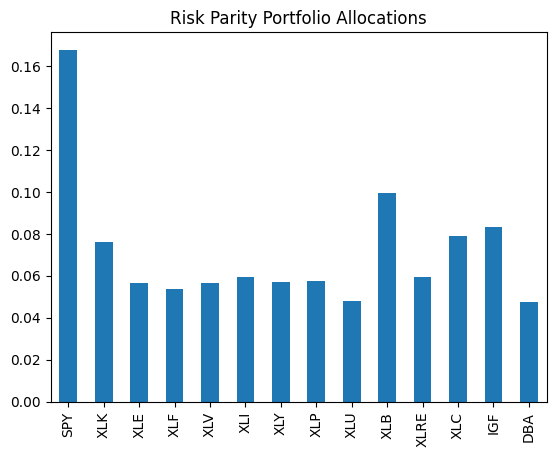

In [32]:
# Visualize
weight_df = pd.Series(weights, index=etf_list)
weight_df.plot(kind='bar', title="Risk Parity Portfolio Allocations")

In [33]:
portfolio_volatility = np.sqrt(weights.T @ shrinkage_matrix @ weights)
print(f"Portfolio Volatility: {portfolio_volatility:.4f}")

Portfolio Volatility: 0.0077
